## GridSearchCV and Pipline

In [1]:
import pandas as pd
df = pd.read_csv("./california_housing_data.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
X = df.drop("target",axis=1)
y = df["target"]

## 建立管道

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import LinearRegression

In [8]:
pipeline = Pipeline([
    ("scaler",StandardScaler()),
    ("regression",LinearRegression())
])

In [6]:
from sklearn.model_selection import train_test_split
# 將數據分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [9]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regression', LinearRegression())])

In [10]:
from sklearn.metrics import mean_squared_error
y_pred = pipeline.predict(X_test)
mean_squared_error(y_test,y_pred)

0.5289841670367208

## GridSearchCV and Pipeline

In [11]:
import pandas as pd
df = pd.read_csv("./california_housing_data.csv")
X = df.drop("target",axis=1)
y = df["target"]

In [12]:
from sklearn.model_selection import train_test_split,GridSearchCV
# 將數據分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import Ridge


In [ ]:
pipeline = Pipeline([
    ("scaler",StandardScaler()),
    ("ridge",Ridge())
])

In [ ]:
parameterd = {
    "ridge__alpha":[0.1,1,10,15,20,25,30]
}
grid_search = GridSearchCV(pipeline,parameterd,cv=5)
grid_search.fit(X_train,y_train)
print(grid_search.best_params_)



{'ridge__alpha': 15}


In [17]:
y_pred = grid_search.predict(X_test)
mean_squared_error(y_test,y_pred)

0.5291802214076735

# KNN - K最近鄰居 - 分類

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("./gene_expression.csv")
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


<Axes: xlabel='Gene One', ylabel='Gene Two'>

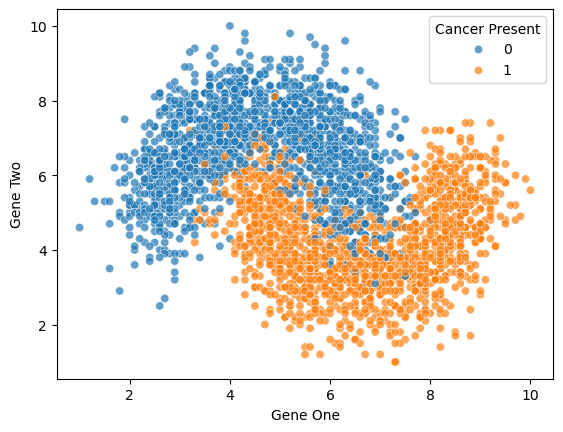

In [20]:
sns.scatterplot(x="Gene One",y="Gene Two",hue="Cancer Present",data=df,alpha=0.7)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
X = df.drop("Cancer Present",axis=1)
y = df["Cancer Present"]


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [25]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn_mode = KNeighborsClassifier(n_neighbors=19)
knn_mode.fit(scaled_X_train,y_train)

KNeighborsClassifier(n_neighbors=19)

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score 
y_pred = knn_mode.predict(scaled_X_test)
accuracy_score(y_test,y_pred)

0.9477777777777778

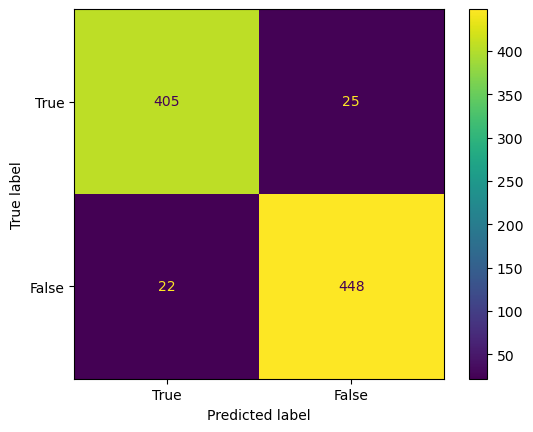

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                              labels=[1, 0],           
                              display_labels=['True', 'False'])

In [34]:
test_error_rates = []
for k in range(1,30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train,y_train) 
   
    y_pred_test = knn_model.predict(scaled_X_test)
    
    test_error = 1 - accuracy_score(y_test,y_pred_test)
    test_error_rates.append(test_error)


Text(0.5, 0, 'K Value')

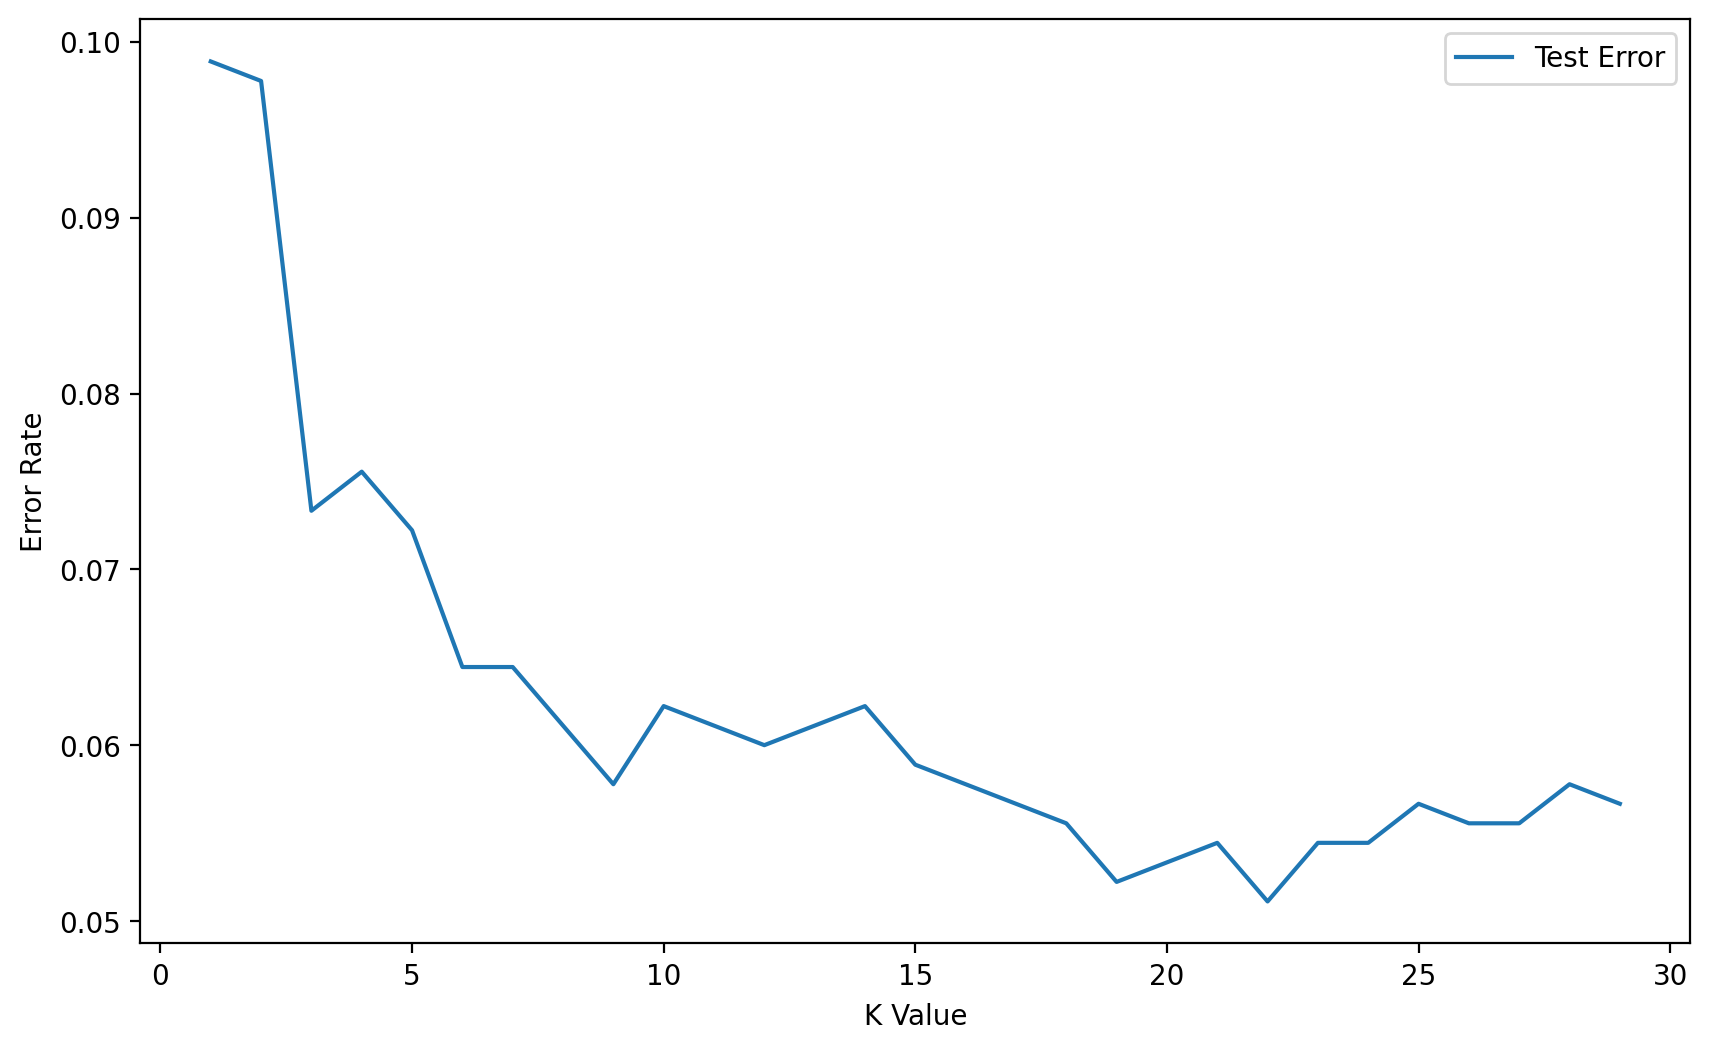

In [35]:
plt.figure(figsize=(10,6),dpi=200)
plt.plot(range(1,30),test_error_rates,label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel("K Value")

In [36]:
for i in range(len(test_error_rates)):
    print(i+1,test_error_rates[i])

1 0.09888888888888892
2 0.09777777777777774
3 0.07333333333333336
4 0.0755555555555556
5 0.07222222222222219
6 0.06444444444444442
7 0.06444444444444442
8 0.061111111111111116
9 0.05777777777777782
10 0.06222222222222218
11 0.061111111111111116
12 0.06000000000000005
13 0.061111111111111116
14 0.06222222222222218
15 0.05888888888888888
16 0.05777777777777782
17 0.05666666666666664
18 0.05555555555555558
19 0.05222222222222217
20 0.053333333333333344
21 0.054444444444444406
22 0.05111111111111111
23 0.054444444444444406
24 0.054444444444444406
25 0.05666666666666664
26 0.05555555555555558
27 0.05555555555555558
28 0.05777777777777782
29 0.05666666666666664


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
df = pd.read_csv("./gene_expression.csv")

In [57]:
X = df.drop("Cancer Present",axis=1)
y = df["Cancer Present"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [58]:
scaler = StandardScaler()
knn = KNeighborsClassifier()
from sklearn.pipeline import Pipeline

In [59]:
oprations = [
    ("scaler",scaler),
    ("knn",knn)
]
pipe = Pipeline(oprations)

In [60]:
from sklearn.model_selection import GridSearchCV

In [62]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [64]:
k_values = list(range(1,25))
param_grid = {"knn__n_neighbors":k_values}
grid_search = GridSearchCV(pipe,param_grid,cv=5,scoring="accuracy")
grid_search.fit(X_train,y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24]},
             scoring='accuracy')

In [65]:
prted =  grid_search.predict(X_test)
accuracy_score(y_test,prted)

0.9466666666666667

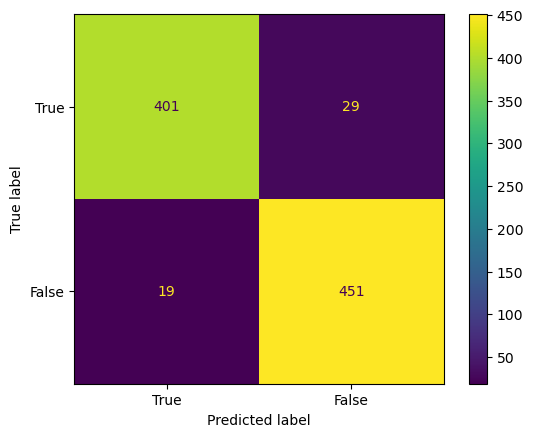

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, prted,
                              labels=[1, 0],           
                              display_labels=['True', 'False'])

# 探索支持向量機（Support Vector Machines, SVM）

**注意：在這個範例中，我們將探討算法，所以我們將跳過數據標準化和訓練/測試拆分，而是看看各種參數如何改變SVM（在分類中最容易視覺化效果）**

[關於SVM的優秀論文鏈接](http://citeseerx.ist.psu.edu/viewdoc/download;jsessionid=4448154647BC7B10C991CEF2236BBA38?doi=10.1.1.114.4288&rep=rep1&type=pdf)
* A tutorial on support vector regression by ALEX J. SMOLA and BERNHARD SCHOLKOPF

## SVM - 分類

### 簡介
支持向量機（Support Vector Machines，SVM）是一種監督學習模型，通常用於分類和回歸分析。SVM的目標是找到一個最佳的超平面來將數據點分開，這個超平面可以最大化邊界（即支持向量）。

### 參數
在探索SVM的過程中，有幾個重要的參數需要理解和調整：
1. **核函數（Kernel Function）**：核函數將低維空間的數據轉換到高維空間，使得數據在高維空間中更容易分離。常見的核函數包括線性核、多項式核和高斯徑向基核（RBF核）。

2. **C參數（正則化參數）**：C值控制的是誤分類的懲罰程度。較小的C值會產生一個更平滑的決策邊界，但可能會容忍更多的誤分類；較大的C值會努力正確分類所有訓練樣本，但可能導致過擬合。

3. **γ參數（gamma）**：γ參數適用於多項式核和RBF核。γ值決定了單個訓練樣本的影響範圍。較大的γ值會使得決策邊界更加複雜，較小的γ值會使得決策邊界更平滑。

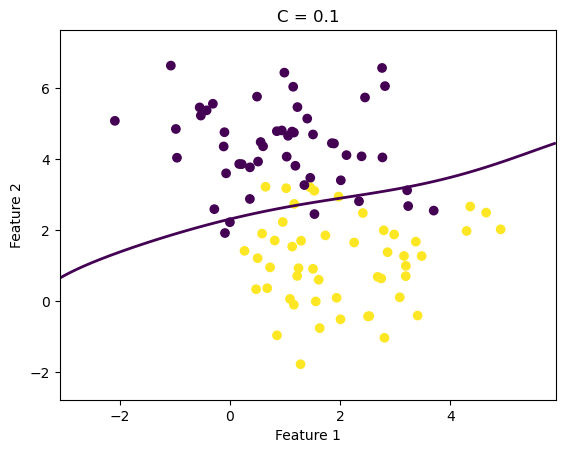

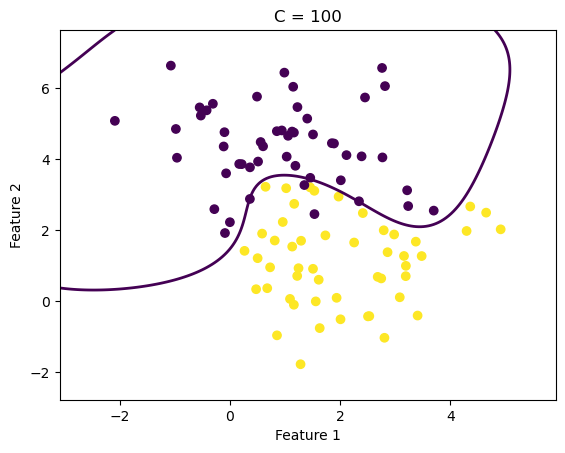

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Generate synthetic data
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)

# Compare decision boundaries for small and large C values
#gamma='scale' 會根據資料特徵的「維度」和「變異程度」自動調整，
for C in [0.1, 100]:
    clf = SVC(kernel='rbf', C=C, gamma='scale')
    clf.fit(X, y)
    
    # Create a mesh to plot decision boundary
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure()
    plt.contour(xx, yy, Z, levels=[0], linewidths=2)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(f'C = {C}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()


## 數據

這裡顯示的數據模擬了一項醫學研究，在該研究中，被病毒感染的小鼠被給予不同劑量的兩種藥物，然後在兩週後檢查它們是否仍然被感染。根據這些數據，我們的目標是創建一個分類模型，預測（給定兩個劑量測量值）小鼠是否仍然會被病毒感染。

你會注意到，這些群組非常容易分離，這是故意設計的，以便探索SVM模型的各種參數如何表現。

In [68]:
df = pd.read_csv("mouse_viral_study.csv")
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


<Axes: xlabel='Med_1_mL', ylabel='Med_2_mL'>

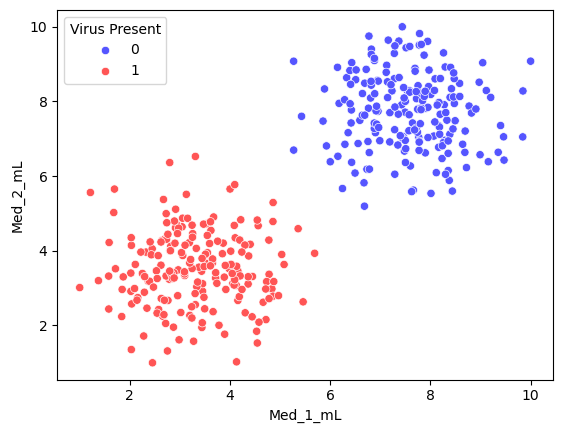

In [69]:
sns.scatterplot(x='Med_1_mL',y='Med_2_mL',hue='Virus Present',
                data=df,palette='seismic')

In [70]:
from sklearn.svm import SVC # Supprt Vector Classifier
import warnings
# 忽略 scikit-learn 的 UserWarning
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [71]:
y = df['Virus Present']
X = df.drop('Virus Present',axis=1)

In [73]:
model = SVC(kernel='linear', C=1000)
model.fit(X, y)

SVC(C=1000, kernel='linear')

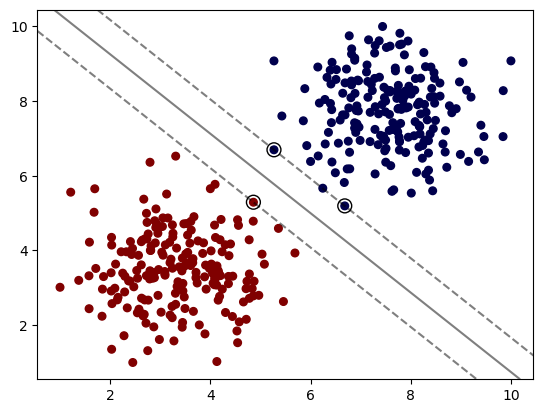

In [74]:
from svm_margin_plot import plot_svm_boundary
plot_svm_boundary(model,X,y)# 繪製SVM決策邊界

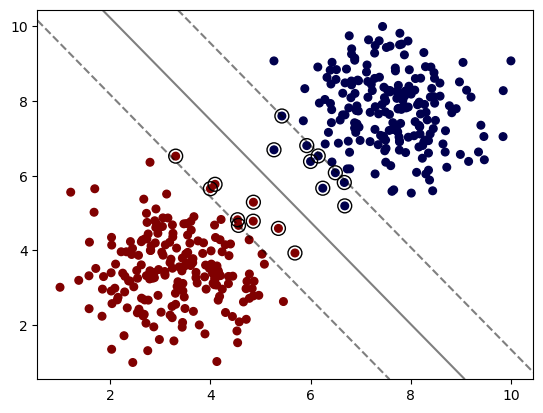

In [75]:
model = SVC(kernel='linear', C=0.05)
model.fit(X, y)
plot_svm_boundary(model,X,y)# 繪製SVM決策邊界

## gamma值的理解

- **gamma值越大**：
  - 模型會更加關注訓練數據中非常接近的資料點。
  - 因為模型更緊密地擬合這些局部數據，所以可能會導致過擬合（overfitting）。

- **gamma值越小**：
  - 模型會考慮更廣泛的資料範圍，訓練時更多地關注整體數據分佈。
  - 因此，模型更均勻地適應數據，但可能會導致欠擬合（underfitting），因為它忽略了數據中的一些細節。

這樣的表述能更清晰地傳達gamma值對模型的影響。

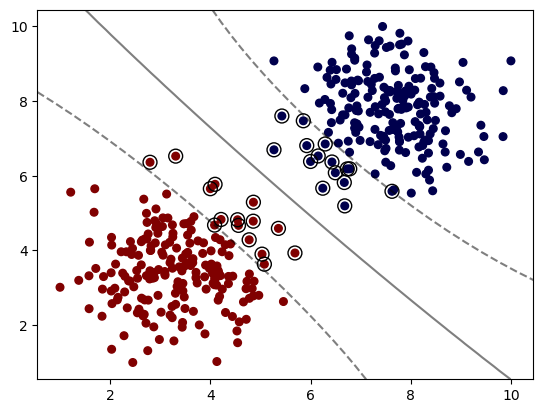

In [76]:
model = SVC(kernel='rbf', C=1,gamma=0.01)
model.fit(X, y)
plot_svm_boundary(model,X,y)

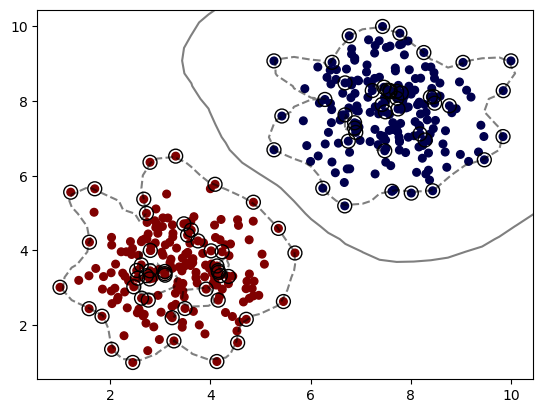

In [77]:
model = SVC(kernel='rbf', C=1,gamma=1)
model.fit(X, y)
plot_svm_boundary(model,X,y)

## 網格搜索

In [78]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import pandas as pd
from sklearn.datasets import make_moons
from sklearn.svm import SVC

# 產生「月牙形」資料（適合 RBF）
X_np, y_np = make_moons(
    n_samples=300,
    noise=0.12,
    random_state=42
)

monX = pd.DataFrame(X_np, columns=["x1", "x2"])
mony = pd.Series(y_np)

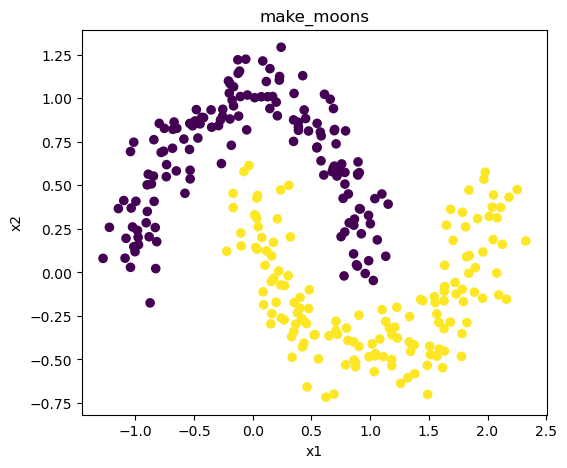

In [79]:
# 畫散點圖
plt.figure(figsize=(6, 5))
plt.scatter(monX["x1"], monX["x2"], c=mony, s=35)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("make_moons")
plt.show()

In [80]:
# 1) 要測的參數範圍（常用：用 10 倍去試）
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [0.001, 0.01, 0.1, 1, 10],
    "kernel": ["rbf"]  # 固定用 rbf，因為你本來就是 rbf
}

In [81]:
# 2) 交叉驗證切法（分類建議用 StratifiedKFold）
#根據資料的分類比例切 例如 1分類 70% 0分類 30%每次切分盡力這個比例 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3) GridSearchCV
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring="accuracy",  
    cv=cv,
)

In [82]:
# 4) 開始找最佳參數
grid.fit(monX, mony)

print("最佳參數:", grid.best_params_)
print("最佳CV分數:", grid.best_score_)

最佳參數: {'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}
最佳CV分數: 1.0


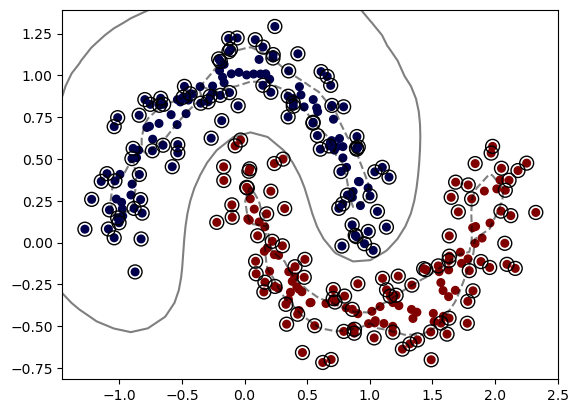

In [83]:
# 5) 直接拿最佳模型來畫（ plot_svm_boundary）
best_model = grid.best_estimator_
plot_svm_boundary(best_model, monX, mony)


我們將使用“Palmer Penguins”數據集，這個數據集足夠簡單，可以幫助我們完全理解超參數改變如何影響分類結果。
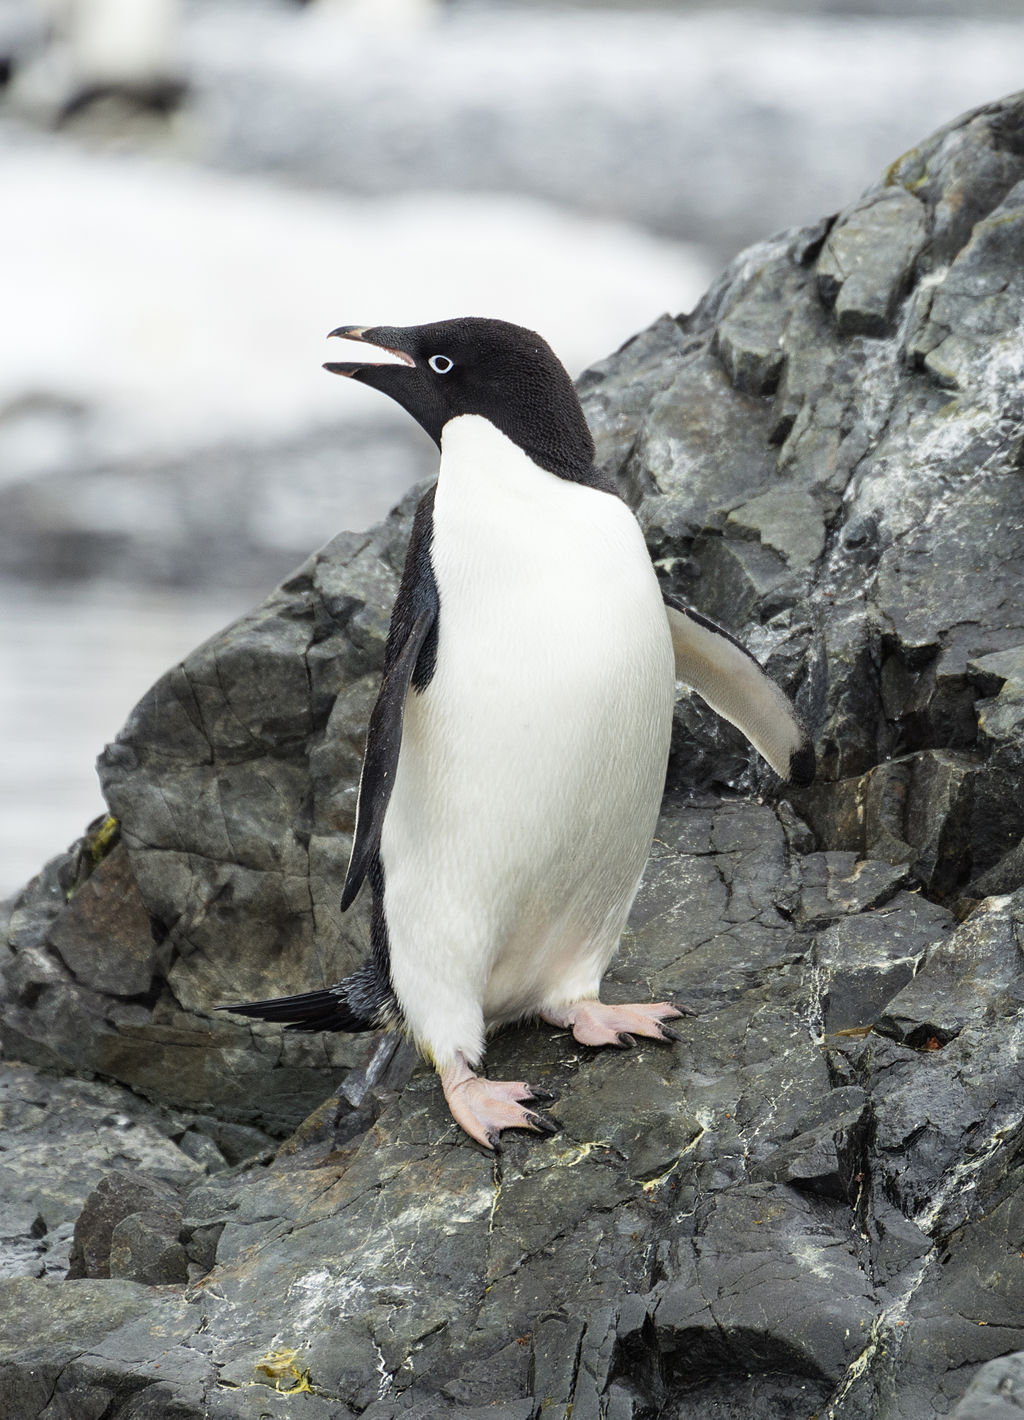

些數據由Dr. Kristen Gorman和Palmer Station，南極LTER（一個長期生態研究網絡的成員）收集並提供。

Gorman KB, Williams TD, Fraser WR (2014) 《Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis)》。PLoS ONE 9(3): e90081. doi:10.1371/journal.pone.0090081



* penguins_size.csv：簡化的數據來自原始企鵝數據集。包含變量：

    * species：企鵝物種（帽帶企鵝、阿德利企鵝或紐帶企鵝）
    * culmen_length_mm：嘴峰長度（毫米）
    * culmen_depth_mm：嘴峰深度（毫米）
    * flipper_length_mm：鰭長度（毫米）
    * body_mass_g：體重（克）
    * island：在Palmer群島（南極洲）的島嶼名稱（Dream, Torgersen或Biscoe）
    * sex：企鵝性別

註：嘴峰是“鳥喙的上脊”

**我們的目標是創建一個模型，該模型可以根據物理屬性幫助預測企鵝的物種，然後我們可以使用該模型幫助研究人員在現場分類企鵝，而無需經驗豐富的生物學家**


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
df = pd.read_csv("penguins_size.csv")
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [86]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [87]:
df.dropna(inplace=True)
df.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [88]:
df["sex"].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [89]:
df = df[df["sex"] != '.']

<Axes: xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

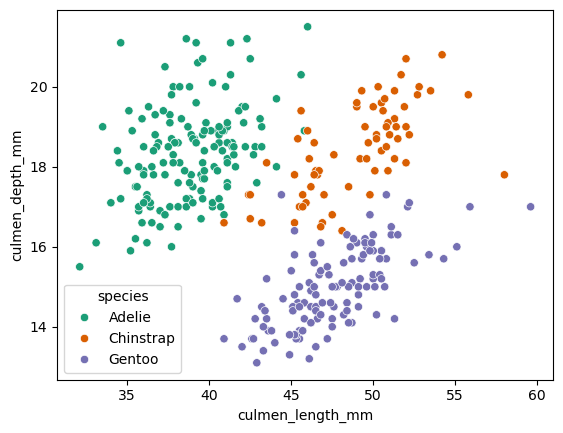

In [90]:
sns.scatterplot(x="culmen_length_mm",y='culmen_depth_mm',data=df,hue="species",palette="Dark2")

In [91]:
X = pd.get_dummies(df.drop('species',axis=1),drop_first=1 )#get_dummies One-Hot Encoding
y = df['species']

In [92]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [93]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [94]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [95]:
base_pred =  model.predict(X_test)

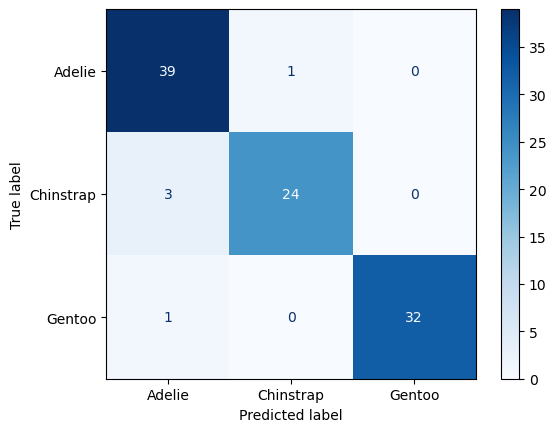

In [96]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
cm  = confusion_matrix(y_test,base_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Visualize the Tree

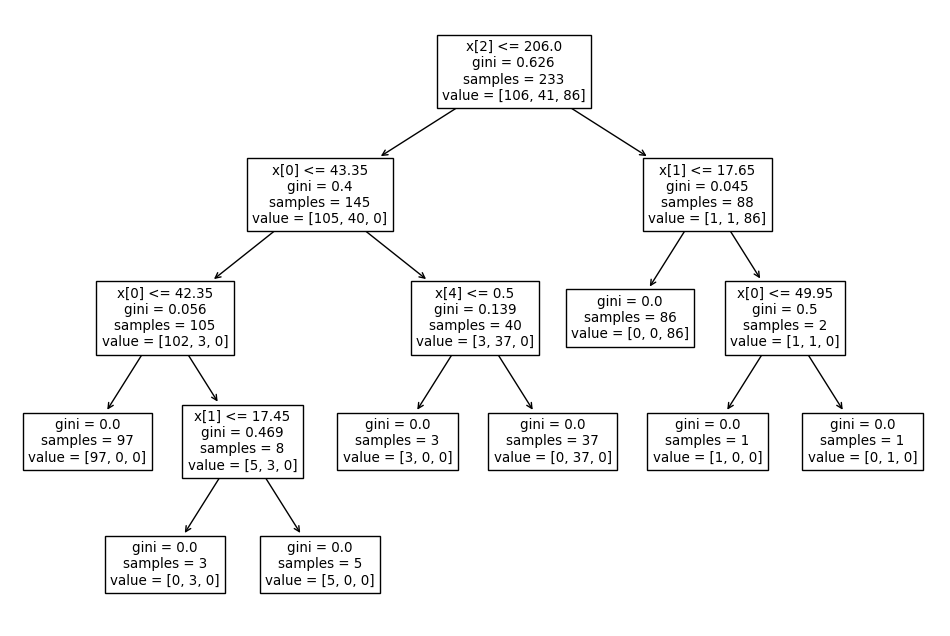

In [97]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model)
plt.show()

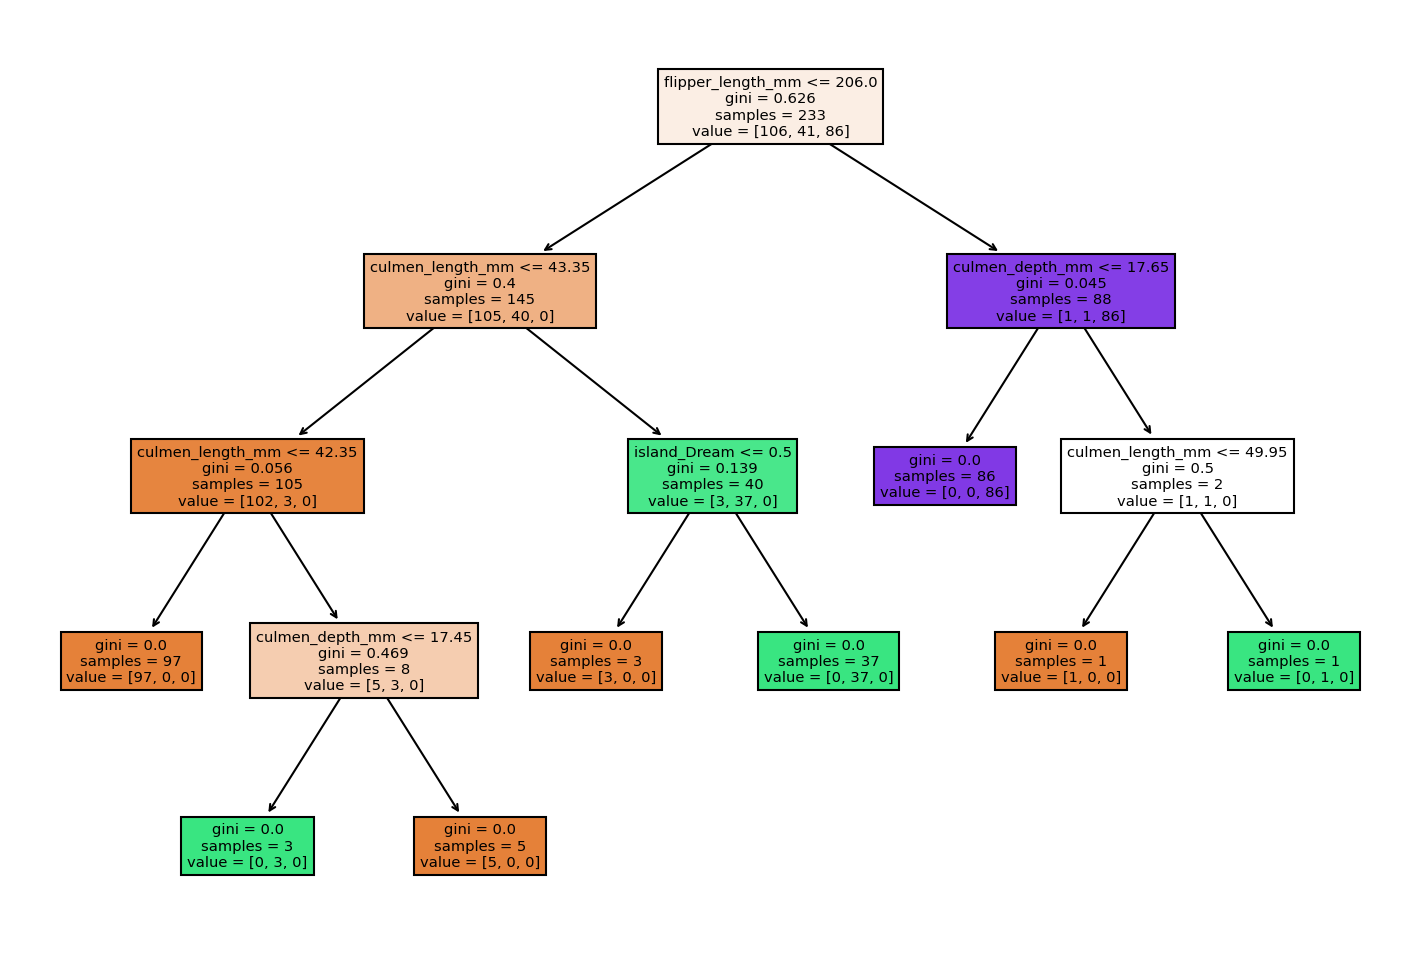

In [98]:
plt.figure(figsize=(12,8),dpi=150)
plot_tree(model,filled=True,feature_names=X.columns)
plt.show()

最佳參數: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
最佳CV分數: 0.9295238095238094
0.9444444444444444


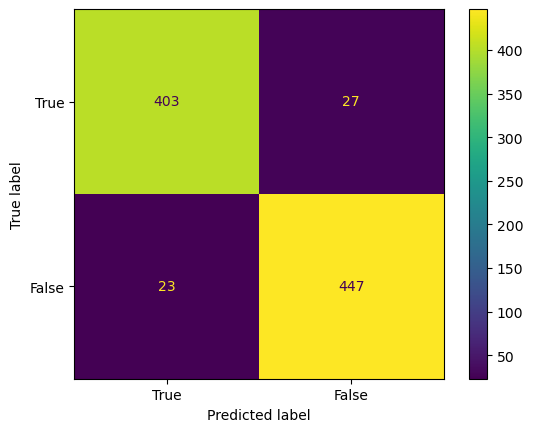

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import pandas as pd
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from svm_margin_plot import plot_svm_boundary
df = pd.read_csv("./gene_expression.csv")
df.head()
X = df.drop("Cancer Present",axis=1)
y = df["Cancer Present"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

# 1) 要測的參數範圍（常用：用 10 倍去試）
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [0.001, 0.01, 0.1, 1, 10],
    "kernel": ["rbf"]  # 固定用 rbf，因為你本來就是 rbf
}
# 2) 交叉驗證切法（分類建議用 StratifiedKFold）
#根據資料的分類比例切 例如 1分類 70% 0分類 30%每次切分盡力這個比例 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3) GridSearchCV
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring="accuracy",  
    cv=cv,
)
# 4) 開始找最佳參數
grid.fit(scaled_X_train, y_train)

print("最佳參數:", grid.best_params_)
print("最佳CV分數:", grid.best_score_)

from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score 
y_pred = grid.predict(scaled_X_test)

print(accuracy_score(y_pred,y_test))
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                              labels=[1, 0],           
                              display_labels=['True', 'False'])


